# Canada Coverage Analysis — 4-Satellite Constellation

End-to-end demonstration of **missiontools** coverage and plotting features with a constellation.

**Scenario**
- 4 satellites in a sun-synchronous orbit, 550 km, 10:30 LTAN (ascending)
- Satellites evenly spaced in the orbital plane (90° separation in mean anomaly)
- Nadir-pointed pushbroom sensor per satellite, 20° half-angle FOV
- Min ground elevation: 20°
- Illumination constraint: solar zenith angle < 70° (daytime)
- Area of interest: Canada (20 000 km² point density)
- Simulation window: 90 days

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from missiontools import Spacecraft, Sensor, AoI, Coverage
from missiontools.plotting import plot_ground_track, plot_coverage_map

## 1. Build the constellation (4 evenly-spaced satellites)

In [2]:
EPOCH = np.datetime64("2025-05-01T00:00:00", "us")

# Get sun-synchronous orbit parameters
sc0 = Spacecraft.sunsync(
    altitude_km=550.0,
    node_solar_time="10:30",
    epoch=EPOCH,
)

# Create 4 satellites evenly spaced in the orbital plane
NUM_SATELLITES = 4
spacecraft_list = []
sensor_list = []

for i in range(NUM_SATELLITES):
    # Create spacecraft with evenly-spaced mean anomaly
    sc = Spacecraft(
        a=sc0.a,
        e=sc0.e,
        i=sc0.i,
        raan=sc0.raan,
        arg_p=sc0.arg_p,
        ma=(2 * np.pi * i) / NUM_SATELLITES,  # 0°, 90°, 180°, 270°
        epoch=sc0.epoch,
        propagator_type="j2",
    )
    
    # Attach nadir-pointed sensor to each satellite
    sensor = Sensor(half_angle_deg=20.0, body_vector=[0, 0, 1])
    sc.add_sensor(sensor)
    
    spacecraft_list.append(sc)
    sensor_list.append(sensor)

print(f"Semi-major axis : {sc0.a/1e3:.1f} km")
print(f"Inclination     : {np.degrees(sc0.i):.2f} deg")
print(f"RAAN            : {np.degrees(sc0.raan):.2f} deg")
print(f"Propagator      : {sc0.propagator_type}")
print(f"Constellation   : {NUM_SATELLITES} satellites @ 0°, 90°, 180°, 270° mean anomaly")

Semi-major axis : 6928.1 km
Inclination     : 97.59 deg
RAAN            : 15.96 deg
Propagator      : j2
Constellation   : 4 satellites @ 0°, 90°, 180°, 270° mean anomaly


## 2. Define the Area of Interest

In [ ]:
# 20 000 km² per sample point  (~141 km spacing)
aoi = AoI.from_geography("Canada", point_density=20_000)
print(f"AoI sample points: {len(aoi)}")

## 3. Set up Coverage analysis

In [4]:
cov = Coverage(
    aoi,
    sensor_list,
    el_min_deg=20.0,
    sza_max_deg=70.0,
)

## 4. Run the 90-day simulation

In [6]:
T_START = EPOCH
T_END   = EPOCH + np.timedelta64(90 * 24 * 3600, "s")

print("Computing coverage fraction ...")
frac = cov.coverage_fraction(T_START, T_END, max_step=np.timedelta64(10, "s"))
print(f"  Final cumulative coverage : {frac["final_cumulative"]:.1%}")
print(f"  Mean instantaneous        : {frac["mean_fraction"]:.1%}")

print("Computing revisit times ...")
rev = cov.revisit_time(T_START, T_END, max_step=np.timedelta64(10, "s"))

Computing coverage fraction ...
  Final cumulative coverage : 100.0%
  Mean instantaneous        : 0.1%
Computing revisit times ...


## 5. Ground tracks — first 24 hours

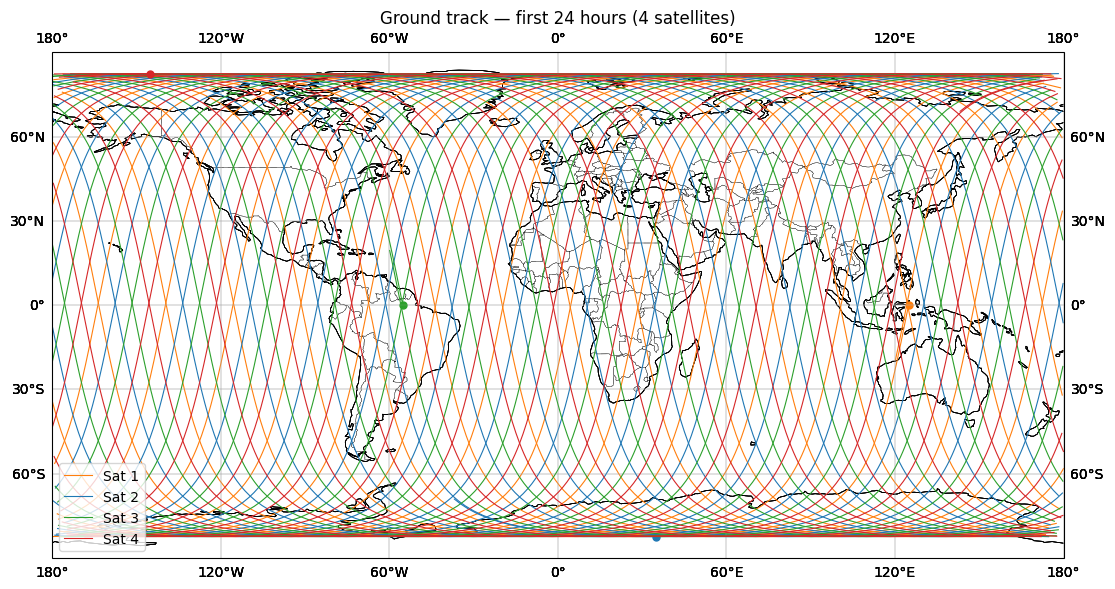

In [7]:
fig = plt.figure(figsize=(14, 6))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

colors = ["tab:orange", "tab:blue", "tab:green", "tab:red"]

for i, sc in enumerate(spacecraft_list):
    plot_ground_track(
        sc,
        T_START,
        T_START + np.timedelta64(24 * 3600, "s"),
        ax=ax,
        color=colors[i],
        label=f"Sat {i+1}",
        linewidth=0.8,
    )

ax.set_title("Ground track — first 24 hours (4 satellites)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 6. Coverage maps over Canada

We use a Lambert Conformal Conic projection with the same geometric parameters
as EPSG:3347 (Statistics Canada Lambert).  We define it manually because
Cartopy's  carries restrictive area-of-use bounds from the
EPSG registry that clip southern Canada out of the renderable area.

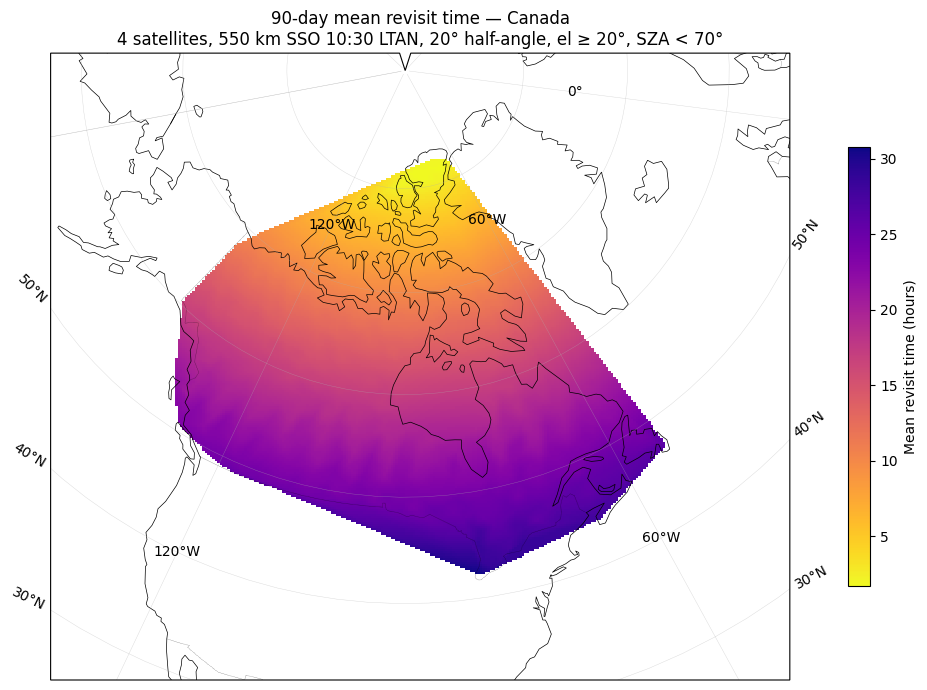

In [8]:
# Statistics Canada Lambert — same geometry as EPSG:3347 but without
# the restrictive area-of-use bounds that clip southern Canada.
canada_proj = ccrs.LambertConformal(
    central_longitude=-91.867,
    central_latitude=63.391,
    standard_parallels=(49, 77),
)

# --- Mean revisit time (hours) -------------------------------------------
mean_rev_hrs = rev["mean_revisit"] / 3600.0  # seconds → hours

fig, ax = plt.subplots(
    figsize=(12, 7),
    subplot_kw={"projection": canada_proj},
)
plot_coverage_map(
    aoi,
    mean_rev_hrs,
    ax=ax,
    auto_window=True,
    cmap="plasma_r",
    colorbar_label="Mean revisit time (hours)",
title="90-day mean revisit time — Canada\n4 satellites, 550 km SSO 10:30 LTAN, 20° half-angle, el ≥ 20°, SZA < 70°",
)
plt.tight_layout()
plt.show()

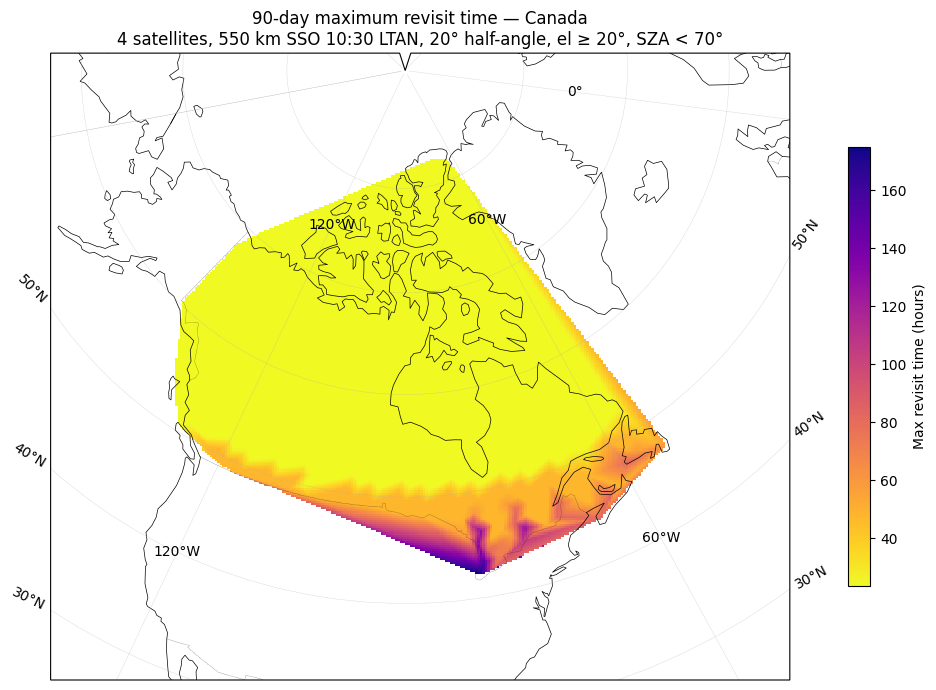

In [9]:
# --- Maximum revisit time (hours) -----------------------------------------
max_rev_hrs = rev["max_revisit"] / 3600.0  # seconds → hours

fig, ax = plt.subplots(
    figsize=(12, 7),
    subplot_kw={"projection": canada_proj},
)
plot_coverage_map(
    aoi,
    max_rev_hrs,
    ax=ax,
    auto_window=True,
    cmap="plasma_r",
    colorbar_label="Max revisit time (hours)",
title="90-day maximum revisit time — Canada\n4 satellites, 550 km SSO 10:30 LTAN, 20° half-angle, el ≥ 20°, SZA < 70°",
)
plt.tight_layout()
plt.show()

## 7. Summary statistics

In [10]:
print("=" * 50)
print("90-day coverage summary — Canada (4-satellite constellation)")
print("=" * 50)
print(f"Cumulative coverage fraction : {frac["final_cumulative"]:.1%}")
print(f"Mean instantaneous coverage  : {frac["mean_fraction"]:.1%}")
print()
global_mean_hrs = rev["global_mean"] / 3600.0
global_max_hrs  = rev["global_max"]  / 3600.0
print(f"Global mean revisit time       : {global_mean_hrs:.1f} h")
print(f"Global max revisit time        : {global_max_hrs:.1f} h")

# Compare with single satellite results from canada_coverage.ipynb
single_mean = 59.8  # hours from single-satellite example
single_max = 893.9  # hours from single-satellite example

print()
print("--- Comparison with single satellite ---")
print(f"Mean revisit time improvement  : {single_mean/global_mean_hrs:.1f}x faster")
print(f"Max revisit time improvement   : {single_max/global_max_hrs:.1f}x faster")

90-day coverage summary — Canada (4-satellite constellation)
Cumulative coverage fraction : 100.0%
Mean instantaneous coverage  : 0.1%

Global mean revisit time       : 17.9 h
Global max revisit time        : 178.1 h

--- Comparison with single satellite ---
Mean revisit time improvement  : 3.3x faster
Max revisit time improvement   : 5.0x faster
